In [2]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
#from osgeo import gdal, osr, gdalconst, gdal_array

In [3]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=8, g=18, r=28):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    im = ax.imshow(img)  # 画像を表示
    plt.show()
    
#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

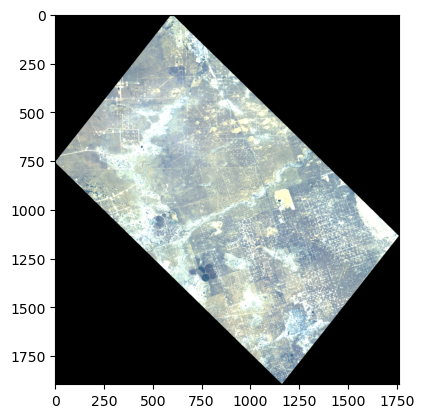

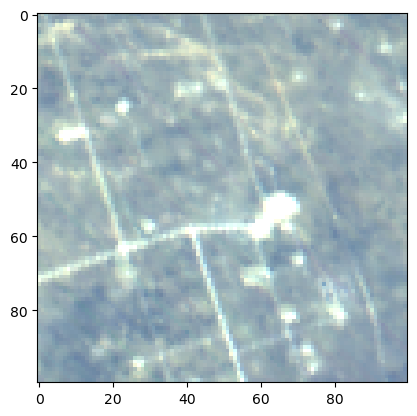

In [4]:
# ファイルの読み込み
file = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.tif"

directory = r"E:\permian_basin\out_prof_ch4"
img = tifffile.imread(file) # read tif file
param = read_bfile(file)    # read radiometric file (..._B.csv)
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)  # read meta file (....txt)
img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)  # apply radiometric parameter
ims = get_rgb(img, b=8, g=18, r=28)
center = np.array([1200, 800]) #中心座標(y, x), ここを変える
#ここで切り取りの範囲を設定
img_slice = img[center[0] - 50 : center[0] + 50, center[1] -50 : center[1] + 50, :] #補正後の画像
ims_slice = ims[center[0] - 50 : center[0] + 50, center[1] -50 : center[1] + 50 , :] #画像表示用の画像
show_img(ims)
show_img(ims_slice)

In [4]:
from scipy.optimize import least_squares
def instrumental_function(data, sigma, mu): #装置関数
    column, row = data.shape #dataはMODTRAN6の結果
    x = data[0, :] #Wavelen
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x) #波長の平均値(中央値)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)) #ガウス関数
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same') #畳み込み
    return out

def extract_h2o(data): #範囲の選択
    return data[:, 645:865] #1025-1244nm

def reflectance_correction(data, a, b, k): #反射率の考慮, 一次近似で良い
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data

def estimated_by_water(data, w): #水の量の推定, 0.25刻みの水を線形補間
    water = np.arange(0, 0.25 * (data.shape[0]-1), 0.25)
    position = np.searchsorted(water, w)
    out = []
    for i in range(data.shape[1]):
        if position + 1 < data.shape[0]:  # インデックスが範囲外にならないようにチェック
            r = (water[position] - w) / 0.25
            interpolated_value = r * data[position, i] + (1 - r) * data[position + 1, i]
        else:
            interpolated_value = data[position, i]  # 最後のインデックスの場合、次の値がないためそのままの値を使用
        out.append(interpolated_value)
    return out

def wavelength_adjustment_h2o(data_water, array, data_hisui):  #波長を線形補間する
    out = []
    wave_width = 1.0 #ここで波長の刻み幅を変える
    for i in range(11,28): #1025.915-1238.245nm
        position = np.searchsorted(array, data_hisui.iloc[i, 0]) #水の場所を求める
        r = (array[position] - data_hisui.iloc[i, 0]) / wave_width 
        out.append(r * data_water[position - 1] + (1 - r) * data_water[position])
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_h2o(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_water(out, w)
    out = wavelength_adjustment_h2o(out, data[0, 645:865], data_hisui)
    return out

def residuals_h2o(param, data, data_hisui):  #残差
    sigma, mu, a, b, w, k = param
    w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
    return data_hisui.iloc[11:28,1] - w_est

def estimate_param_h2o(data, data_hisui): #bの推定
    max_ref = max(data_hisui.iloc[11:28,1]) #1025.915-1238.245nm
    rel_max_index = np.argmax(data_hisui.iloc[11:28,1])
    abs_max_index = data_hisui.iloc[11:28].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    out = instrumental_function(data, sigma=6.5, mu=0.0)
    out = extract_h2o(out)
    out = estimated_by_water(out, w=0.0)
    out = wavelength_adjustment_h2o(out, data[0, 645:865], data_hisui)
    modtran = out[rel_max_index]
    b = max_ref / max_wave / modtran
    return b

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path

# CSVパス
csv_path = Path(r"E:\permian_basin\out_prof_ch4\ch_h2ostr_merged_avg_170_180.csv")

# 読み込み（列: Waveln, 1.60, 1.65, ..., 2.00）
df = pd.read_csv(csv_path)

# 先頭列=波長, 残り=各濃度 → instrumental_function が期待する
# 形式（先頭行が波長ベクトル）に並べ替え
waves = df.iloc[:, 0].to_numpy(dtype=float)                 # (N_waves,)
vals  = df.iloc[:, 1:].to_numpy(dtype=float).T              # (N_levels, N_waves)

# data_co2: 先頭行が波長、以降が各濃度のスペクトル
data_co2 = np.vstack([waves[np.newaxis, :], vals])          # (1 + N_levels, N_waves)
print(data_co2)


[[3.80000e+02 3.81000e+02 3.82000e+02 ... 2.49800e+03 2.49900e+03
  2.50000e+03]
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.03097e-01 5.43152e-01
  4.50556e-01]
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.03064e-01 5.43002e-01
  4.50523e-01]
 ...
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.02899e-01 5.42256e-01
  4.50362e-01]
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.02866e-01 5.42107e-01
  4.50329e-01]
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.02833e-01 5.41958e-01
  4.50297e-01]]


In [6]:
import numpy as np
import pandas as pd

# ---- HISUI側の4点スライス：既定 108:112、足りなければ末尾4点 ----
def _get_hisui_window(data_hisui):
    """
    既定: iloc[108:112]（4点: 108,109,110,111）。
    行数が112未満なら末尾4点を使用。
    返り値: (target_waves, target_reflectance, idx_slice)
    """
    n = len(data_hisui)
    if n >= 113:
        idx = slice(107, 113)
    elif n >= 4:
        idx = slice(n - 4, n)
    else:
        raise ValueError(f"data_hisui が短すぎます (len={n})。少なくとも4行必要です。")

    waves = data_hisui.iloc[idx, 0].to_numpy(dtype=float)  # (4,)
    refl  = data_hisui.iloc[idx, 1].to_numpy(dtype=float)  # (4,)
    return waves, refl, idx

# ---- 以降は名前据え置き。166:170 参照をすべて _get_hisui_window 経由に統一 ----

def extract_co2(data):  # 波長窓はそのまま
    return data[:, 1868:1918]

def estimated_by_co2(data, c):
    # 濃度(=1.60〜2.00, 0.05刻み) の補間
    levels = np.round(1.60 + 0.05 * np.arange(data.shape[0], dtype=float), 2)
    return np.array([np.interp(c, levels, data[:, j], left=data[0, j], right=data[-1, j])
                     for j in range(data.shape[1])], dtype=float)

def wavelength_adjustment_co2(data_co2, array, data_hisui):
    """
    data_co2 を HISUI の 108:112 の波長へ線形補間
    """
    target_waves, _, _ = _get_hisui_window(data_hisui)  # (4,)
    return np.interp(target_waves, array.astype(float), data_co2.astype(float),
                     left=float(data_co2[0]), right=float(data_co2[-1]))

def func_co2(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, 1868:1918], data_hisui)  # -> (4,)
    return out

def residuals_co2(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    w_est = func_co2(data, data_hisui, sigma, mu, a, b, c, k)     # (4,)
    _, obs_ref, _ = _get_hisui_window(data_hisui)              # (4,)
    return obs_ref - w_est

def estimate_param_co2(data, data_hisui):
    """
    a, b の推定（y_ratio = obs/model ≈ a*λ + b を 4点で一次近似）。
    返り値は (b, a)。
    """
    # 入力の形は呼び出し元で整っている前提（必要なら以前の _as_ndarray2d を併用）
    target_waves, obs_ref, _ = _get_hisui_window(data_hisui)

    # 基準 c_ref（グリッド中央）
    c_ref = 1.80

    # モデル → 同じ4波長へ補間
    mod = instrumental_function(data, sigma=6.5, mu=0.0)
    mod = extract_co2(mod)
    mod = estimated_by_co2(mod, c=c_ref)
    mod = np.interp(target_waves, data[0, 1868:1918].astype(float), mod.astype(float),
                    left=float(mod[0]), right=float(mod[-1]))

    if np.any(mod == 0.0) or np.any(~np.isfinite(mod)) or np.any(~np.isfinite(obs_ref)):
        raise ValueError("モデル/観測に 0 or 非有限値が含まれます。前処理を確認してください。")

    # 一次回帰（4点）
    y_ratio = obs_ref / mod
    a, b = np.polyfit(target_waves, y_ratio, 1)  # y ≈ a*λ + b

    return b, a


In [7]:
#装置関数と二酸化炭素量の最小二乗法の実行
#1950.175-2100.055nm
H,W,C= img_slice.shape
out_co2 = np.empty((H,W,5))
for y in range(H):
    print(y)
    for x in range(W):
        data_rad = get_radiance(img_slice, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
        if np.max(df.iloc[:,1]) == 0:
            out_co2[y,x,:] =  0
        else:
            b, a = estimate_param_co2(data_co2, df)
            a0 =  np.array([7.0, 0.0, a, b, 1.8, 1])
            res = least_squares(residuals_co2, a0, args=(data_co2, df), method="lm")
            out_co2[y,x,0] =  res.x[0] #sigma
            out_co2[y,x,1] =  res.x[1] #mu
            out_co2[y,x,2] =  res.x[2] #a
            out_co2[y,x,3] =  res.x[3] #b
            out_co2[y,x,4] =  res.x[4] #co2


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


<Axes: >

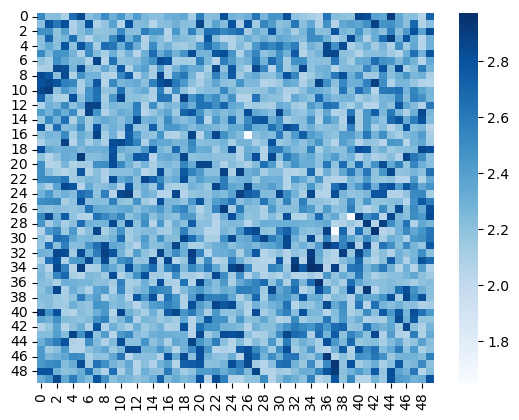

In [9]:
sns.heatmap(out_co2[:, :, 4], cmap="Blues")

In [6]:
#水蒸気量の最小二乗法
def instrumental_function(data, sigma, mu): #装置関数
    column, row = data.shape #dataはMODTRAN6の結果
    x = data[0, :] #Wavelen
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x) #波長の平均値(中央値)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)) #ガウス関数
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode="same") #畳み込み
    return out

def extract_h2o(data): #範囲の選択
    return data[:, 645:865] #1025-1244nm

def reflectance_correction(data, a, b, k): #反射率の考慮, 一次近似で良い
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data

def estimated_by_water(data, w): #水の量の推定, 0.25刻みの水を線形補間
    water = np.arange(0, 0.25 * (data.shape[0]-1), 0.25)
    position = np.searchsorted(water, w)
    out = []
    for i in range(data.shape[1]):
        if position + 1 < data.shape[0]:  # インデックスが範囲外にならないようにチェック
            r = (water[position] - w) / 0.25
            interpolated_value = r * data[position, i] + (1 - r) * data[position + 1, i]
        else:
            interpolated_value = data[position, i]  # 最後のインデックスの場合、次の値がないためそのままの値を使用
        out.append(interpolated_value)
    return out

def wavelength_adjustment_h2o(data_water, array, data_hisui):  #波長を線形補間する
    out = []
    wave_width = 1.0 #ここで波長の刻み幅を変える
    for i in range(11,28): #1025.915-1238.245nm
        position = np.searchsorted(array, data_hisui.iloc[i, 0]) #水の場所を求める
        r = (array[position] - data_hisui.iloc[i, 0]) / wave_width
        out.append(r * data_water[position - 1] + (1 - r) * data_water[position])
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_h2o(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_water(out, w)
    out = wavelength_adjustment_h2o(out, data[0, 645:865], data_hisui)
    return out

def residuals_h2o(param, data, data_hisui):  #残差
    sigma, mu, a, b, w, k = param
    w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
    return data_hisui.iloc[11:28,1] - w_est

def estimate_param_h2o(data, data_hisui): #a, bの推定
    out = instrumental_function(data, sigma=6.5, mu=0.0)
    out = extract_h2o(out)
    out = estimated_by_water(out, w=2.0)
    out = wavelength_adjustment_h2o(out, data[0, 645:865], data_hisui)
    out = np.array(out)
    highlight_points = [0, 1, 2, 15, 16] #2037.605, 2087.565nm
    x = data_hisui.iloc[11:28, 0].iloc[highlight_points]
    y = data_hisui.iloc[11:28, 1].iloc[highlight_points] / out[highlight_points]
    coefficients = np.polyfit(x, y, 1)
    return coefficients #[0]がb, [1]がaとなることに注意 

In [14]:
#装置関数と二酸化炭素の最小二乗法
def extract_co2(data): #範囲の選択
    return data[:, 1868:1918]
def estimated_by_co2(data, c):
    # co2 軸を data の行数にぴったり合わせる（上限含む）
    co2 = np.linspace(1.6, 1.6 + 0.05 * (data.shape[0]-1), data.shape[0])
    pos = np.searchsorted(co2, c, side='left')

    out = []
    for i in range(data.shape[1]):
        if pos == 0:
            # 下端未満 → 最初の値
            interpolated_value = data[0, i]
        elif pos == len(co2):
            # 上端超え → 最後の値
            interpolated_value = data[-1, i]
        else:
            x0, x1 = co2[pos-1], co2[pos]
            t = (c - x0) / (x1 - x0)   # 0..1
            interpolated_value = (1 - t) * data[pos-1, i] + t * data[pos, i]
        out.append(interpolated_value)
    return out

def wavelength_adjustment_co2(data_co2, array, data_hisui):
    out = []
    arr = np.asarray(array, dtype=float)  # 1D 昇順前提
    vals = np.asarray(data_co2, dtype=float)  # 同じ長さ

    for i in range(107, 113):
        target = float(data_hisui.iloc[i, 0])
        pos = np.searchsorted(arr, target, side='left')

        if pos == 0:
            out.append(vals[0])          # 下端未満 → 端値
            continue
        if pos == len(arr):
            out.append(vals[-1])         # 上端超え → 端値
            continue

        x0, x1 = arr[pos-1], arr[pos]
        y0, y1 = vals[pos-1], vals[pos]
        t = (target - x0) / (x1 - x0)    # 0..1
        out.append((1 - t) * y0 + t * y1)
    return out


def func_co2(data, data_hisui, sigma, mu, a, b, c, k):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, 1868:1918], data_hisui)
    return out

def residuals_co2(param, data, data_hisui):  #残差
    sigma, mu, a, b, c, k = param
    w_est = func_co2(data, data_hisui, sigma, mu, a, b, c, k)
    return data_hisui.iloc[107:113,1] - w_est

def estimate_param_co2(data, data_hisui): #bの推定
    out = instrumental_function(data, sigma=6.0, mu=0.0)
    out = extract_co2(out)
    out = estimated_by_co2(out, c=1.8)
    out = wavelength_adjustment_co2(out, data[0, 1868:1918], data_hisui)
    out = np.array(out)
    highlight_points = [1,2,4] #1987.645, 2037.605, 2087.565nm
    x = data_hisui.iloc[107:113, 0].iloc[highlight_points]
    y = data_hisui.iloc[107:113, 1].iloc[highlight_points] / out[highlight_points]
    coefficients = np.polyfit(x, y, 1)
    return coefficients #[0]がb, [1]がaとなることに注意 

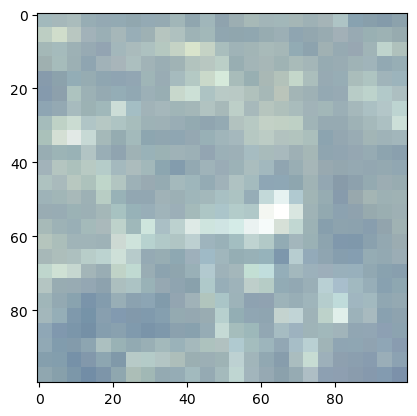

In [12]:
def average_pooling(img, G): #平均プーリング
    H, W, C = img.shape  
    Nh = H // G  
    Nw = W // G  
    out = np.zeros((Nh, Nw, C))
    for y in range(Nh):
        for x in range(Nw):
            for c in range(C):
                out[y,x,c] = np.mean(img[G*y:G*(y+1), G*x:G*(x+1), c])
    return out

def return_pooling(img, G):
    H, W, C = img.shape
    Nh = H * G  
    Nw = W * G  
    out = np.zeros((Nh, Nw, C))
    for y in range(H):
        for x in range(W):
            for c in range(C):
                out[G*y:G*(y+1), G*x:G*(x+1), c] = img[y,x,c]
    return out

img_slice_pooling = average_pooling(img_slice, G=4)
ims_slice_pooling = return_pooling(average_pooling(ims_slice, G=4), G=4)
show_img(ims_slice_pooling)

In [15]:
#装置関数と二酸化炭素量の最小二乗法の実行
H,W,C= img_slice_pooling.shape
out_co2 = np.empty((H,W,4))
for y in range(H):
    for x in range(W):
        data_rad = get_radiance(img_slice_pooling, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
        if np.max(df.iloc[:,1]) == 0:
            out_co2[y,x,:] =  0
        else:
            b, a = estimate_param_co2(data_co2, df)
            a0 =  np.array([6.0, 0.0, a, b, 1.8, 0.0])
            res = least_squares(residuals_co2, a0, args=(data_co2, df), method="lm")
            out_co2[y,x,0] =  res.x[0] #sigma
            out_co2[y,x,1] =  res.x[1] #mu
            out_co2[y,x,2] =  res.x[4] #co2
            out_co2[y,x,3] =  np.sum(residuals_co2(res.x, data_co2, df))

The average of sigma is  3.049437980276866
The average of sigma is  2.810593721096496
The average of CO2 is  2.0905393055421957
The average of CO2 is  2.0941313600157856


Text(0.5, 1.0, 'Amounts of CO2')

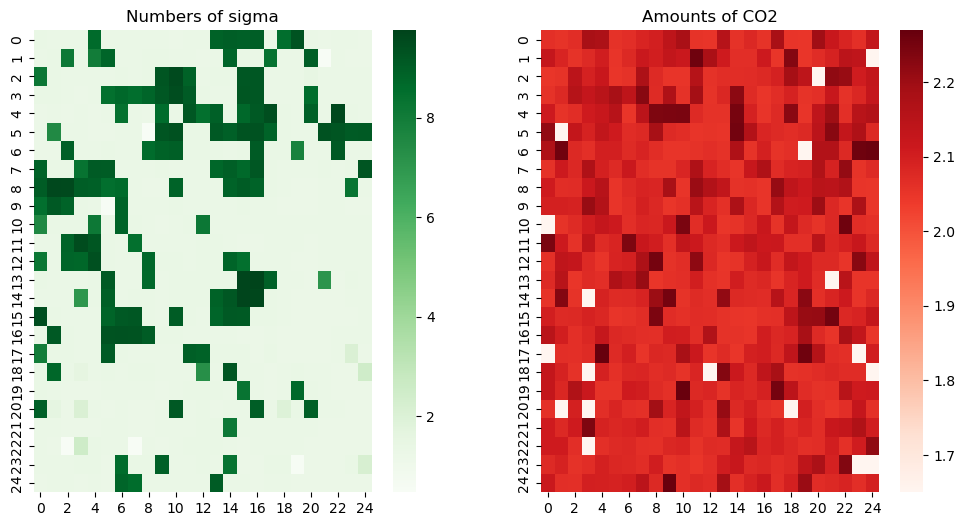

In [16]:
print("The average of sigma is ", np.average(out_co2[:, :, 0]))
print("The average of sigma is ", np.average(out_co2[7:19, 5:27, 0]))
print("The average of CO2 is ", np.average(out_co2[:, :, 2]))
print("The average of CO2 is ", np.average(out_co2[7:19, 5:27, 2]))
fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.heatmap(out_co2[:, :, 0], cmap="Greens", ax=axes[0])
axes[0].set_title("Numbers of sigma")
sns.heatmap(out_co2[:, :, 2], cmap="Reds", ax=axes[1])
axes[1].set_title("Amounts of CO2")

In [17]:
H,W,C= img_slice.shape
out_co2 = np.empty((H,W,4))
for y in range(H):
    for x in range(W):
        data_rad = get_radiance(img_slice, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
        if np.max(df.iloc[:,1]) == 0:
            out_co2[y,x,:] =  0
        else:
            b, a = estimate_param_co2(data_co2, df)
            a0 =  np.array([6.0, 0.0, a, b, 1.8, 0.0])
            res = least_squares(residuals_co2, a0, args=(data_co2, df), method="lm")
            out_co2[y,x,0] =  res.x[0] #sigma
            out_co2[y,x,1] =  res.x[1] #mu
            out_co2[y,x,2] =  res.x[4] #co2
            out_co2[y,x,3] =  np.sum(residuals_co2(res.x, data_co2, df))

The average of sigma is  3.216293739625669
The average of sigma is  2.526835389750097
The average of CO2 is  2.087656626513241
The average of CO2 is  2.084848044374253


Text(0.5, 1.0, 'Amounts of CO2')

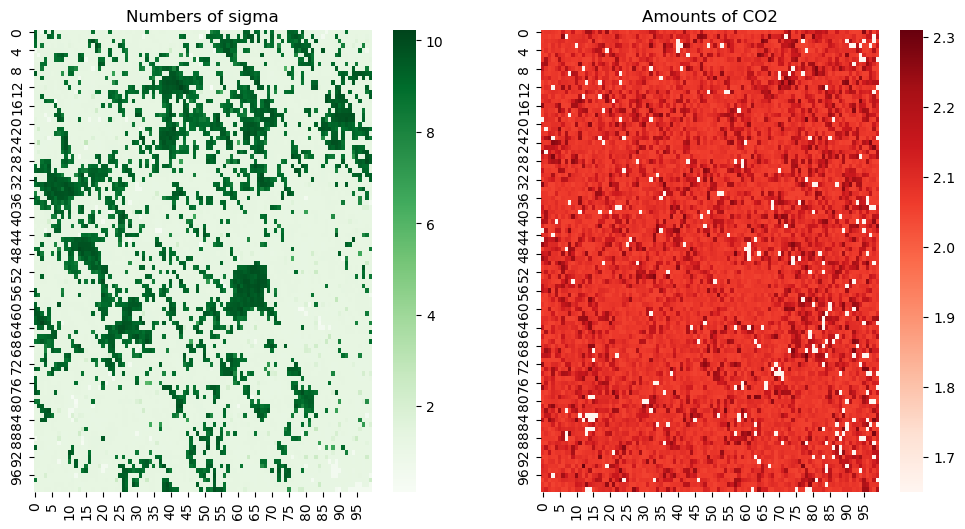

In [18]:
print("The average of sigma is ", np.average(out_co2[:, :, 0]))
print("The average of sigma is ", np.average(out_co2[7:19, 5:27, 0]))
print("The average of CO2 is ", np.average(out_co2[:, :, 2]))
print("The average of CO2 is ", np.average(out_co2[7:19, 5:27, 2]))
fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.heatmap(out_co2[:, :, 0], cmap="Greens", ax=axes[0])
axes[0].set_title("Numbers of sigma")
sns.heatmap(out_co2[:, :, 2], cmap="Reds", ax=axes[1])
axes[1].set_title("Amounts of CO2")